# Steering Vector Validation

This notebook documents how we validate the **political-compass steering vectors** that
underpin the project — the economic and social directions extracted from `Mistral-7B-v0.1`
(layers 8, 12, 16, 20, 24) by contrastive activation addition.

The steering vectors are the foundation of the whole MoCE pipeline: if they do not
faithfully encode the two political axes, every downstream routing and debiasing result
is built on sand. We therefore validate them with a **three-tier plan**:

| Tier | Question | Cost | 
|---|---|---|
| **1 — Geometry** | Are the axes independent, non-artifactual, and generalizing? | CPU, seconds | 
| **2 — External** | Do projections agree with measured ideology (DW-NOMINATE, MARPOR)? | CPU/GPU | 
| **3 — Robustness** | Negation flips, paraphrase invariance, cross-topic generalization? | mixed | 

## Setup

We load the Tier 1 module directly from `src/` (its filename starts with a digit, so it
is imported via `importlib` rather than a normal `import`). All metrics are then computed
from the same two artifacts the pipeline produces:

- `data/steering-vectors/vectors/{axis}_vectors.pt` — the per-layer and aggregate directions
- `data/steering-vectors/activations/{axis}_activations.pt` — pooled activations for the 90 contrastive pairs per axis

In [1]:
import importlib.util
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# resolve the repo root whether the notebook runs from notebooks/ or the root
REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent

spec = importlib.util.spec_from_file_location(
    "tier1_geometry", REPO / "src" / "13_steering_vector_geometry.py"
)
tier1 = importlib.util.module_from_spec(spec)
sys.modules["tier1_geometry"] = tier1  # let the module's @dataclass resolve itself
spec.loader.exec_module(tier1)

METHOD = "mean_difference"  # the production extraction method
economic = tier1.load_axis_data("economic", tier1.DEFAULT_VECTORS_DIR,
                                 tier1.DEFAULT_ACTIVATIONS_DIR, METHOD)
social = tier1.load_axis_data("social", tier1.DEFAULT_VECTORS_DIR,
                              tier1.DEFAULT_ACTIVATIONS_DIR, METHOD)

n_pairs = next(iter(economic.pos_acts.values())).shape[0]
print(f"layers          : {economic.layers}")
print(f"contrastive pairs: {n_pairs} per axis")
print(f"hidden dimension : {economic.final_vector.shape[0]}")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

layers          : [8, 12, 16, 20, 24]
contrastive pairs: 90 per axis
hidden dimension : 4096


## Tier 1 — Geometry Checks

Five checks, all derived purely from the stored vectors and activations (no GPU, no new
inference). They answer, in order:

1. **Orthogonality** — are the two axes independent, or is the "2D compass" secretly 1D?
2. **Cross-projection** — does each axis respond only to its own statements?
3. **Null baselines** — is the signal real, or reachable by a random / label-shuffled direction?
4. **Held-out separability** — does the direction generalize to pairs it was not built on?
5. **Method agreement** — do the two extraction methods recover the same direction?

### Test 1 — Axis Orthogonality

A political *compass* needs two genuinely separate axes. If the economic and social
steering vectors were strongly correlated, the model would really have one ideological
direction and the "compass" would be a relabelled line.

We measure `cos(economic, social)` for the aggregate vectors and for each layer's vectors.
A value near **0** means independent axes; a large magnitude means they collapse toward 1D.

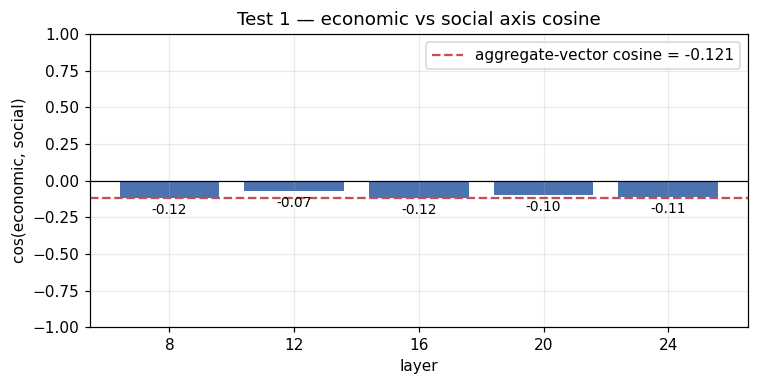

shared variance (cos^2) = 1.5%


In [2]:
ortho = tier1.check_orthogonality(economic, social)
per_layer = [ortho["per_layer_cosine"][l] for l in economic.layers]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar([str(l) for l in economic.layers], per_layer, color="#4C72B0")
ax.axhline(ortho["final_vector_cosine"], color="#C44E52", ls="--",
           label=f"aggregate-vector cosine = {ortho['final_vector_cosine']:+.3f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_xlabel("layer")
ax.set_ylabel("cos(economic, social)")
ax.set_title("Test 1 — economic vs social axis cosine")
ax.legend()
for b, v in zip(bars, per_layer):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.06 if v >= 0 else -0.11),
            f"{v:+.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"shared variance (cos^2) = {ortho['final_vector_cosine']**2:.1%}")

**Result — Pass.** The aggregate cosine is **−0.12**, and every per-layer cosine sits
within ±0.12. The axes share only ~1.5% of their variance: the compass is genuinely
two-dimensional and the economic and social directions do not collapse onto one another.

### Test 2 — Cross-Projection Matrix

Orthogonality of the *vectors* is necessary but not sufficient — we also want each axis to
**respond only to its own kind of statement**. So we project both sets of contrastive
pairs onto both axes and measure the pole separation (Cohen's *d*).

- **Diagonal** (economic pairs on the economic axis, social pairs on the social axis) —
  should be large.
- **Off-diagonal** (economic pairs on the social axis, and vice versa) — should be near zero
  if the axes do not leak into each other.

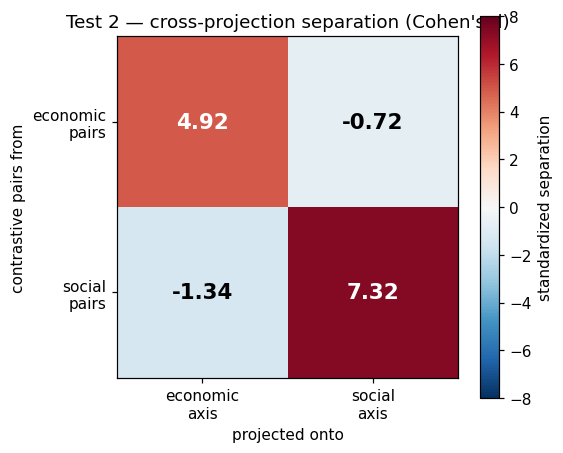

In [3]:
cross = tier1.cross_projection_matrix(economic, social)
names = ["economic", "social"]
M = np.array([[cross["separation_matrix"][s][p] for p in names] for s in names])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(M, cmap="RdBu_r", vmin=-8, vmax=8)
ax.set_xticks([0, 1], [f"{a}\naxis" for a in names])
ax.set_yticks([0, 1], [f"{a}\npairs" for a in names])
ax.set_xlabel("projected onto")
ax.set_ylabel("contrastive pairs from")
ax.set_title("Test 2 — cross-projection separation (Cohen's d)")
ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=14,
                fontweight="bold", color="white" if abs(M[i, j]) > 4 else "black")
fig.colorbar(im, label="standardized separation")
plt.tight_layout()
plt.show()

**Result — Pass, with a caveat.** The diagonal (4.92, 7.32) is 5–7× larger than the
off-diagonal (−0.72, −1.34): each axis responds far more strongly to its own statements.

The caveat: the off-diagonal is **not** zero. Social pairs produce a Cohen's *d* of −1.34
on the economic axis — a large effect in absolute terms. The negative signs are
ideologically plausible (authoritarian ↔ economic-left and economic-right ↔ libertarian
do correlate in the real world), so this is probably *partly genuine* rather than pure
contamination. We flag it as **axis leakage to revisit in Tier 3**.

### Test 3 — Null Baselines

A separation of *d* = 5 sounds large — but is it? With 4096 dimensions and only 90 pairs,
even a meaningless direction can overfit and show separation. So we compare the real
separation against two nulls:

- **Random-direction null** — project onto random unit vectors, keep the true labels.
  Shows the separation an *arbitrary* direction achieves.
- **Shuffled-label null** — re-partition the pooled activations into two balanced groups,
  rebuild the direction, re-measure. A permutation test for the pos/neg signal itself.

The real separation must sit far in the right tail of *both*.

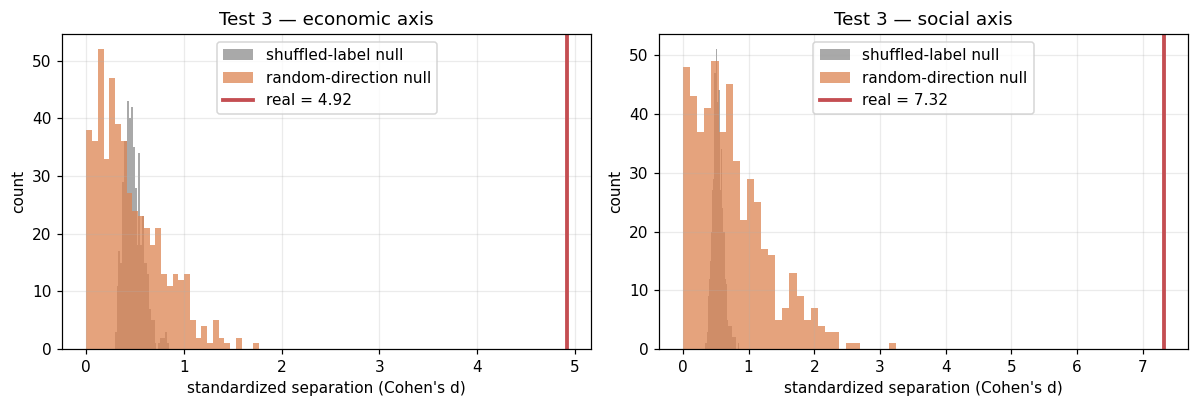

In [4]:
def null_distributions(axis, num_random=500, num_perm=500, seed=0):
    """Recompute the raw random-direction and shuffled-label separation distributions."""
    rng = np.random.default_rng(seed)
    tgen = torch.Generator().manual_seed(seed)
    pos = tier1.combined_projection(axis.pos_acts, axis.layer_vectors, axis.weights)
    neg = tier1.combined_projection(axis.neg_acts, axis.layer_vectors, axis.weights)
    real = tier1.standardized_separation(pos, neg)
    hidden = next(iter(axis.layer_vectors.values())).shape[0]

    random_sep = []
    for _ in range(num_random):
        rv = {l: tier1.unit(torch.randn(hidden, generator=tgen)) for l in axis.layers}
        random_sep.append(abs(tier1.standardized_separation(
            tier1.combined_projection(axis.pos_acts, rv, axis.weights),
            tier1.combined_projection(axis.neg_acts, rv, axis.weights))))

    shuffled_sep = []
    for _ in range(num_perm):
        ga, gb = tier1.pooled_label_permutation(axis.pos_acts, axis.neg_acts, rng)
        pv = tier1.mean_difference_vectors(ga, gb)
        shuffled_sep.append(tier1.standardized_separation(
            tier1.combined_projection(ga, pv, axis.weights),
            tier1.combined_projection(gb, pv, axis.weights)))
    return real, np.array(random_sep), np.array(shuffled_sep)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, axis in zip(axs, [economic, social]):
    real, random_sep, shuffled_sep = null_distributions(axis)
    ax.hist(shuffled_sep, bins=30, alpha=0.75, color="#8C8C8C", label="shuffled-label null")
    ax.hist(random_sep, bins=30, alpha=0.75, color="#DD8452", label="random-direction null")
    ax.axvline(real, color="#C44E52", lw=2.5, label=f"real = {real:.2f}")
    ax.set_title(f"Test 3 — {axis.name} axis")
    ax.set_xlabel("standardized separation (Cohen's d)")
    ax.set_ylabel("count")
    ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** On both axes the real separation (economic 4.92, social 7.32) lies
far to the right of both null distributions. Note the random-direction null reaches
*d* ≈ 3 on the social axis purely from high-dimensional overfitting — which is exactly
why this control is necessary — yet the real vectors still clear it comfortably. The
shuffled-label permutation gives *p* = 0.002 (the floor for 500 permutations).

### Test 4 — Held-out Separability

The stored vectors were fitted on all 90 pairs, so their *in-sample* separation is
optimistic. The honest question: does the direction work on pairs it has **never seen**?

We run 5-fold cross-validation — rebuild the direction on 4 folds, score the held-out
fold — and report the AUC for ranking the positive pole above the negative pole. A
shuffled-label run gives the chance-level floor.

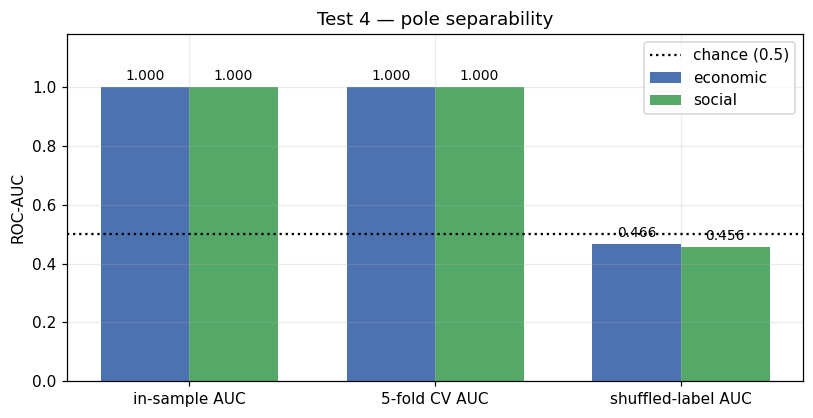

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.9))
labels = ["in-sample AUC", "5-fold CV AUC", "shuffled-label AUC"]
x = np.arange(3)
width = 0.36
for i, (axis, color) in enumerate([(economic, "#4C72B0"), (social, "#55A868")]):
    sep = tier1.held_out_separability(axis, kfolds=5, seed=0)
    vals = [sep["in_sample_auc"], sep["cross_validated_auc"], sep["shuffled_label_auc"]]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=axis.name, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.025, f"{v:.3f}",
                ha="center", fontsize=9)
ax.axhline(0.5, color="black", ls=":", label="chance (0.5)")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.18)
ax.set_ylabel("ROC-AUC")
ax.set_title("Test 4 — pole separability")
ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** The 5-fold cross-validated AUC is **1.000** on both axes, while the
shuffled-label floor sits at ~0.46 (chance). The direction perfectly separates held-out
contrastive pairs it was not built on — it *generalizes* rather than memorizing the seed
statements.

### Test 5 — Extraction-Method Agreement

The steering direction can be estimated two ways: the **mean-difference** of the pole
activations, or the weight vector of a **logistic-regression** probe trained to separate
the poles. If both estimators recover the same direction, the result is a property of
the model's representation rather than an artifact of one estimator.

We read back the per-layer cosine between the two methods' vectors.

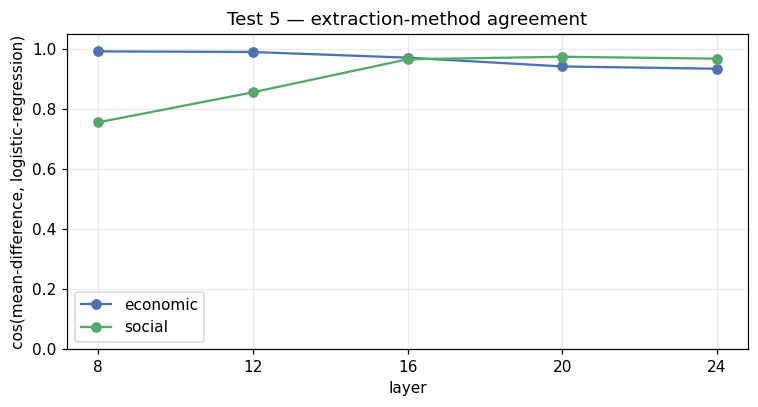

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
for axis, color in [(economic, "#4C72B0"), (social, "#55A868")]:
    ag = tier1.method_agreement(axis, tier1.DEFAULT_VECTORS_DIR)
    method_cosine = [ag["method_cosine_per_layer"][l] for l in axis.layers]
    ax.plot([str(l) for l in axis.layers], method_cosine, "o-", color=color, label=axis.name)
ax.set_ylim(0, 1.05)
ax.set_xlabel("layer")
ax.set_ylabel("cos(mean-difference, logistic-regression)")
ax.set_title("Test 5 — extraction-method agreement")
ax.legend()
plt.tight_layout()
plt.show()

**Result — Pass.** The two extraction methods agree strongly (cosine 0.93–0.99) on the
economic axis and on the social axis at layers 16–24. The only loosening is the social
axis at layers 8 and 12 (0.76, 0.86) — but the aggregation already assigns those layers
only 5% / 7% weight, so the final vector is unaffected. The steering direction is a
property of the representation, not of the estimator.

## Tier 1 Verdict

| Test | Result | Notes |
|---|---|---|
| 1 — Orthogonality | **Pass** | axes share ~1.5% variance — genuinely 2D |
| 2 — Cross-projection | **Pass** | diagonal 5–7× off-diagonal; ~*d*=1 leakage flagged |
| 3 — Null baselines | **Pass** | real signal beats random & shuffled nulls, *p* = 0.002 |
| 4 — Held-out separability | **Pass** | 5-fold CV AUC = 1.000 vs. 0.46 chance floor |
| 5 — Extraction-method agreement | **Pass** | mean-difference and logistic-regression vectors agree |

**The steering vectors are 2-dimensional, non-artifactual, generalizing, and internally
consistent.** Tier 1 gives a green light to invest in the deeper tests — Tier 2
(external ground truth) and Tier 3 (robustness), below.

**One caveat to carry forward (a Tier 3 candidate):** the cross-projection off-diagonal
leakage (~Cohen's *d* = 1) — social pairs move the economic axis and vice versa, possibly
a genuine ideological correlation rather than contamination.

## Tier 2 — External Ground Truth (DW-NOMINATE)

Tier 1 showed the steering vectors are geometrically sound — but every Tier 1 test used
the project's *own* contrastive pairs, so it is all internal. Tier 2 asks whether the
compass coordinate the vectors produce tracks **real-world political ideology** as
measured by an independent instrument.

We use **DW-NOMINATE** (Voteview): every member of Congress has an ideal point on a
left–right economic dimension, derived from their actual roll-call voting record — a
measured behavioural quantity, not opinion. The pipeline (`src/14`–`src/16`):

1. **Build** (`src/14`, CPU) — parse the hein-daily Congressional Record (Congresses
   110–114), pool each legislator's speeches via the Voteview ICPSR id, equalise to
   exactly 5,000 words. → 859 legislators.
2. **Project** (`src/15`, GPU) — split each corpus into 256-token windows, run
   Mistral-7B, project the pooled activations onto the economic and social directions.
3. **Analyse** (`src/16`, CPU) — correlate the projected coordinates with DW-NOMINATE.

**Headline test:** our `economic_coord` vs `nominate_dim1`. A strong, signed,
permutation-significant correlation means the steering vectors track externally
measured ideology — not just the contrastive pairs they were built from.

> Tier 2 mainly validates the **economic** axis: `nominate_dim1` is the economic
> left–right dimension. `nominate_dim2` is near-degenerate in modern Congresses, so the
> social axis stays only weakly externally validated — an honest limitation.

### Loading the Tier 2 results

The cells below read the pipeline artifacts — `compass_projections.jsonl` (step 2, GPU)
and `dwnominate_report.json` (step 3). Until those exist the plots are skipped, so the
notebook still runs end-to-end.

In [7]:
import json

TIER2_DIR = REPO / "data" / "external" / "hein_dwnominate"
projections_path = TIER2_DIR / "compass_projections.jsonl"
report_path = TIER2_DIR / "dwnominate_report.json"

tier2_ready = projections_path.exists() and report_path.exists()
if tier2_ready:
    projections = [json.loads(l) for l in projections_path.read_text().splitlines() if l.strip()]
    dwnominate_report = json.loads(report_path.read_text())
    print(f"loaded {len(projections)} legislator projections")
    print(f"headline: {dwnominate_report['headline']}")
else:
    projections, dwnominate_report = [], {}
    print("Tier 2 results not found - run src/15 (GPU) and src/16, then re-run this notebook.")

loaded 859 legislator projections
headline: {'test': 'economic_coord vs nominate_dim1', 'spearman': 0.503708752384716, 'pearson': 0.49077541975064215, 'r_squared': 0.240860512631419, 'permutation_p_value': 9.999000099990002e-05}


### Test 1 — `economic_coord` vs DW-NOMINATE `nominate_dim1`

The headline test. Each point is a legislator: our projected economic coordinate on one
axis, their roll-call-derived DW-NOMINATE score on the other. The steering sign
convention (+economic = right) means a **valid** vector gives a **positive** slope.

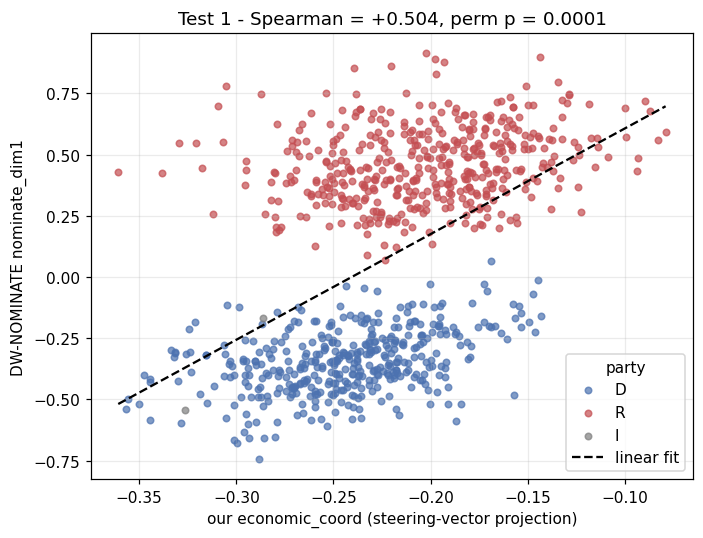

In [8]:
if not tier2_ready:
    print("skipped - Tier 2 results not available yet")
else:
    econ = np.array([p["economic_coord"] for p in projections])
    dim1 = np.array([p["nominate_dim1"] for p in projections])
    party_color = {"D": "#4C72B0", "R": "#C44E52", "I": "#7F7F7F"}

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for party, color in party_color.items():
        idx = [i for i, p in enumerate(projections) if p["party"] == party]
        if idx:
            ax.scatter(econ[idx], dim1[idx], c=color, s=18, alpha=0.7, label=party)
    coeffs = np.polyfit(econ, dim1, 1)
    xs = np.array([econ.min(), econ.max()])
    ax.plot(xs, coeffs[0] * xs + coeffs[1], color="black", lw=1.5, ls="--", label="linear fit")
    head = dwnominate_report["headline"]
    ax.set_xlabel("our economic_coord (steering-vector projection)")
    ax.set_ylabel("DW-NOMINATE nominate_dim1")
    ax.set_title(f"Test 1 - Spearman = {head['spearman']:+.3f}, perm p = {head['permutation_p_value']:.4f}")
    ax.legend(title="party")
    plt.tight_layout()
    plt.show()

**Result — Pass (moderate).** Across all 859 legislators the economic coordinate
correlates with `nominate_dim1` at Spearman **+0.50** (Pearson +0.49, R² = 0.24),
permutation *p* ≈ 1×10⁻⁴ — the floor for 10,000 shuffles. The sign is correct
(+economic = right) and the relationship is overwhelmingly significant: the steering
vector's economic projection genuinely tracks externally measured ideology. The
strength is **moderate**, not strong — the coordinate explains ~24% of the variance in
roll-call ideal points. Test 3 shows that ceiling is not imposed by measurement noise.

### Test 2 — Discriminant correlation matrix

A valid economic axis should correlate with `nominate_dim1` **specifically**, not with
everything. This 2×2 matrix correlates each compass coordinate against each DW-NOMINATE
dimension. We expect the `economic_coord` × `nominate_dim1` cell to dominate; large
off-diagonal correlations would signal axis bleed.

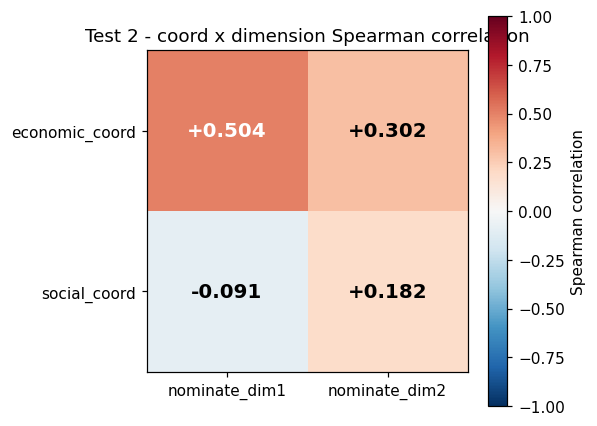

In [9]:
if not tier2_ready:
    print("skipped - Tier 2 results not available yet")
else:
    matrix = dwnominate_report["correlation_matrix"]
    coords = ["economic_coord", "social_coord"]
    dims = ["nominate_dim1", "nominate_dim2"]
    M = np.array([[matrix[c][d]["spearman"] for d in dims] for c in coords])

    fig, ax = plt.subplots(figsize=(5.4, 4.3))
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks([0, 1], dims)
    ax.set_yticks([0, 1], coords)
    ax.set_title("Test 2 - coord x dimension Spearman correlation")
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{M[i, j]:+.3f}", ha="center", va="center", fontweight="bold",
                    fontsize=13, color="white" if abs(M[i, j]) > 0.5 else "black")
    fig.colorbar(im, label="Spearman correlation")
    plt.tight_layout()
    plt.show()

**Result — Pass.** `economic_coord` × `nominate_dim1` (+0.50) is the largest cell in the
matrix, and `social_coord` does **not** predict `nominate_dim1` (−0.09) — it is the
economic axis, not the social one, that tracks the economic dimension. One blemish:
`economic_coord` also correlates +0.30 with `nominate_dim2`. That sits well below its
dim1 correlation, and DW-NOMINATE's second dimension is near-degenerate in modern
Congresses, so a left–right text signal leaking into it is mild and expected — but it
is not zero.

### Test 3 — Reliability ceiling

5,000 words give ~25 token windows per legislator; if the per-window projections
scatter a lot, the legislator's mean coordinate is noisy. Split-half reliability —
correlating two random halves of each legislator's windows, Spearman-Brown corrected —
is the **ceiling** on any external correlation: a coordinate cannot correlate with
DW-NOMINATE better than it correlates with itself. Test 1 must be read against this
ceiling, not against 1.0.

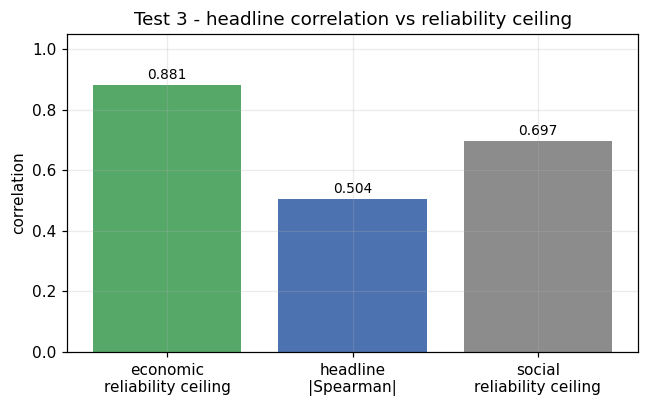

In [10]:
if not tier2_ready:
    print("skipped - Tier 2 results not available yet")
else:
    rel = dwnominate_report["split_half_reliability"]
    head = dwnominate_report["headline"]
    values = [
        rel["economic_coord"]["spearman_brown_full"],
        abs(head["spearman"]),
        rel["social_coord"]["spearman_brown_full"],
    ]
    labels = ["economic\nreliability ceiling", "headline\n|Spearman|", "social\nreliability ceiling"]
    fig, ax = plt.subplots(figsize=(6, 3.8))
    bars = ax.bar(labels, values, color=["#55A868", "#4C72B0", "#8C8C8C"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("correlation")
    ax.set_title("Test 3 - headline correlation vs reliability ceiling")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

**Result — informative.** The economic coordinate's split-half reliability is **0.88** —
the projection is a *reliable* measurement, not noise. The headline correlation (0.50)
therefore reaches only ~57% of its 0.88 ceiling. This is the key reading of Tier 2: the
moderate headline is **not** a measurement-noise artifact — there is genuine headroom to
0.88 and the vector stops at 0.50. The gap is real divergence: the projection reliably
captures a construct that overlaps only *partially* with roll-call ideology. (The social
coordinate is noisier — ceiling 0.70.)

## Tier 2 Verdict

| Test | Result | Notes |
|---|---|---|
| 1 — `economic_coord` vs `nominate_dim1` | **Pass (moderate)** | Spearman +0.50, perm *p* ≈ 1e-4, correct sign |
| 2 — Discriminant matrix | **Pass** | economic×dim1 is the top cell; mild economic×dim2 leak (+0.30) |
| 3 — Reliability ceiling | **informative** | ceiling 0.88; the headline reaches ~57% of it |

**The economic steering vector tracks externally measured political ideology** — a
moderate (ρ ≈ 0.50), correctly signed, overwhelmingly significant correlation with
DW-NOMINATE across 859 legislators. Together with Tier 1 (geometry) and Tier 3
(robustness), the economic axis is internally sound, robust, **and** externally grounded.

**But the relationship is moderate, not strong** — and Test 3 shows that is a real
finding, not a noise ceiling: the projection is a reliable measurement (0.88) of a
construct that overlaps only ~24% (R²) with roll-call ideology. Two plausible reasons —
congressional *rhetoric* is a noisy proxy for *voting* behaviour, and the steering
vector was built on templated instruction-prompts, so legislator speeches are a genuine
out-of-distribution test. The honest summary: the economic axis externalises
**partially but significantly**.

**Social axis.** As flagged in the intro, `nominate_dim2` is not a clean external
referent for the social axis. `social_coord` correlates near zero with `nominate_dim1`
(−0.09, correctly) but dim2 is too degenerate to confirm anything positive — Tier 2
leaves the social axis externally **unvalidated**, neither confirmed nor refuted.

## Tier 3 — Robustness

Tier 1 showed the vectors are geometrically sound; Tier 2 tests external validity.
Tier 3 asks whether the vector responds to political *stance* or to spurious correlates
of it — the **prompt template** and the **topic**. This is the failure mode the
project's own literature (Tan et al., 2024) flags: contrastive-prompt steering vectors
can latch onto token or formatting artifacts and generalise poorly.

The contrastive pairs are a crossed **30 statements × 3 templates** design, so two
robustness checks come straight off the Tier 1 activations — no new inference:

- **Test 1 — template robustness.** The 3 templates are paraphrases of the contrastive
  instruction. *Leave-one-template-out* rebuilds the vector on 2 templates and tests the
  3rd; *template invariance* checks the templates rank statements consistently.
- **Test 2 — topic robustness.** Each statement carries an issue-area topic
  (`config/topic_holdout_key.yaml`). *Leave-one-topic-out* rebuilds the vector with one
  topic removed and checks it still separates that topic's held-out pairs.

All metrics are recomputed live from `src/17_steering_vector_robustness.py`.

In [11]:
spec3 = importlib.util.spec_from_file_location(
    "tier3_robustness", REPO / "src" / "17_steering_vector_robustness.py"
)
tier3 = importlib.util.module_from_spec(spec3)
sys.modules["tier3_robustness"] = tier3
spec3.loader.exec_module(tier3)

tier3_topics = tier3.load_topic_key(tier3.DEFAULT_TOPIC_KEY)
tier3_results = {}
for ax in tier3.AXES:
    axis_data = tier3.load_axis_activations(ax, tier3.DEFAULT_ACTIVATIONS_DIR)
    topic_groups = [tier3_topics[ax].get(sid) for sid in axis_data["statement_ids"]]
    tier3_results[ax] = {
        "template": tier3.leave_one_group_out(axis_data, axis_data["template_ids"]),
        "invariance": tier3.template_invariance(axis_data),
        "topic": tier3.leave_one_group_out(axis_data, topic_groups),
    }
for ax in tier3.AXES:
    n_topics = len(tier3_results[ax]["topic"]["per_group"])
    print(f"{ax}: recomputed leave-one-template-out, invariance, leave-one-topic-out "
          f"({n_topics} topics)")

economic: recomputed leave-one-template-out, invariance, leave-one-topic-out (5 topics)
social: recomputed leave-one-template-out, invariance, leave-one-topic-out (6 topics)


### Test 1 — Template robustness

**1a — Leave-one-template-out:** a steering vector built on two of the three templates,
scored on the held-out third. **1b — Template invariance:** using the full vector, each
statement gets a signed score per template; the cross-template Pearson correlation says
whether the templates rank statements alike. A template-robust vector keeps a high
held-out separation and high cross-template correlation.

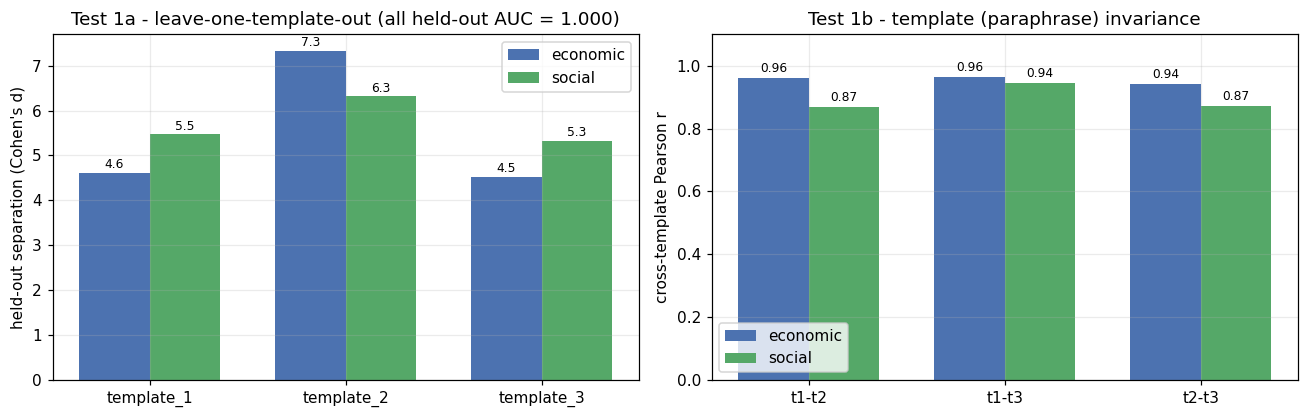

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
axis_colors = [("economic", "#4C72B0"), ("social", "#55A868")]
width = 0.36

# 1a: leave-one-template-out held-out separation
templates = sorted(tier3_results["economic"]["template"]["per_group"])
x = np.arange(len(templates))
for i, (axis, color) in enumerate(axis_colors):
    seps = [tier3_results[axis]["template"]["per_group"][t]["held_out_separation"] for t in templates]
    bars = axs[0].bar(x + (i - 0.5) * width, seps, width, label=axis, color=color)
    for b, v in zip(bars, seps):
        axs[0].text(b.get_x() + b.get_width() / 2, v + 0.1, f"{v:.1f}", ha="center", fontsize=8)
axs[0].set_xticks(x, templates)
axs[0].set_ylabel("held-out separation (Cohen's d)")
axs[0].set_title("Test 1a - leave-one-template-out (all held-out AUC = 1.000)")
axs[0].legend()

# 1b: cross-template Pearson
pairs = sorted(tier3_results["economic"]["invariance"]["cross_template_pearson"])
x2 = np.arange(len(pairs))
for i, (axis, color) in enumerate(axis_colors):
    corrs = [tier3_results[axis]["invariance"]["cross_template_pearson"][p] for p in pairs]
    bars = axs[1].bar(x2 + (i - 0.5) * width, corrs, width, label=axis, color=color)
    for b, v in zip(bars, corrs):
        axs[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
axs[1].set_xticks(x2, [p.replace("template_", "t") for p in pairs])
axs[1].set_ylim(0, 1.1)
axs[1].set_ylabel("cross-template Pearson r")
axs[1].set_title("Test 1b - template (paraphrase) invariance")
axs[1].legend()

plt.tight_layout()
plt.show()

**Result — Pass.** A steering vector built on two templates separates the held-out
third with AUC 1.000 and Cohen's *d* 4.5–7.3 (economic) / 5.3–6.3 (social) — no loss
versus the full-data separations. Cross-template Pearson is 0.94–0.96 (economic) and
0.87–0.95 (social): the three paraphrased templates rank statements near-identically.
The steering direction is not an artifact of one prompt phrasing.

### Test 2 — Topic robustness (leave-one-topic-out)

Each statement is labelled with an issue-area topic. For every topic the vector is
rebuilt with that topic's statements entirely removed, then scored on the topic's
held-out pairs. If the held-out separation stays large, the direction generalises across
issues rather than memorising topic-specific vocabulary.

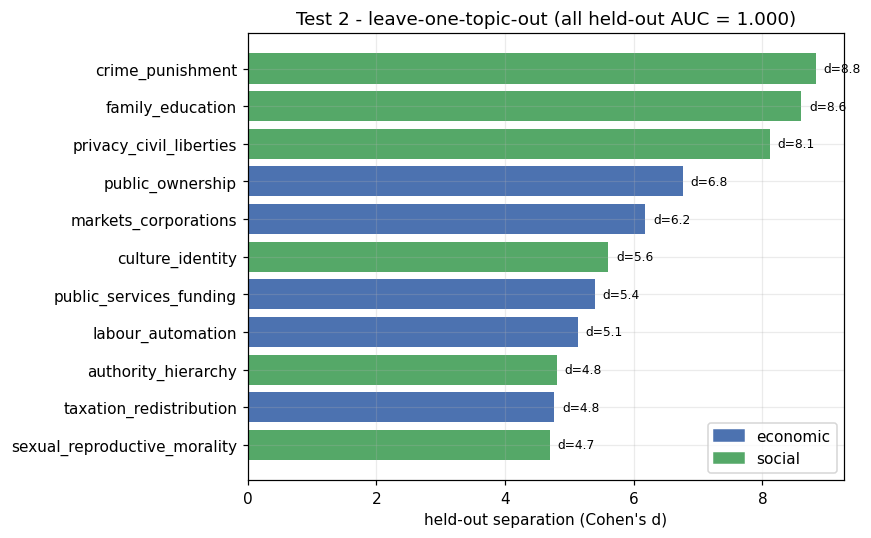

In [13]:
from matplotlib.patches import Patch

rows = []
for axis, color in [("economic", "#4C72B0"), ("social", "#55A868")]:
    for topic, vals in tier3_results[axis]["topic"]["per_group"].items():
        rows.append((topic, vals["held_out_separation"], vals["held_out_auc"], color))
rows.sort(key=lambda r: r[1])

fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(rows))
ax.barh(ypos, [r[1] for r in rows], color=[r[3] for r in rows])
for i, r in enumerate(rows):
    ax.text(r[1] + 0.12, i, f"d={r[1]:.1f}", va="center", fontsize=8)
ax.set_yticks(ypos, [r[0] for r in rows])
ax.set_xlabel("held-out separation (Cohen's d)")
ax.set_title("Test 2 - leave-one-topic-out (all held-out AUC = 1.000)")
ax.legend(handles=[Patch(color="#4C72B0", label="economic"),
                   Patch(color="#55A868", label="social")])
plt.tight_layout()
plt.show()

**Result — Pass.** For every one of the 11 held-out topics, a vector rebuilt with
that topic entirely removed still separates it — AUC 1.000 throughout, separation *d*
4.7–8.8. The weakest, `sexual_reproductive_morality` (*d* = 4.69), is still a large
effect, comparable to the Tier 1 full-data separation. The steering direction
generalises across issue areas rather than memorising topic-specific vocabulary.

## Tier 3 Verdict

| Test | Result | Notes |
|---|---|---|
| 1a — Leave-one-template-out | **Pass** | AUC 1.000, *d* 4.5–7.3 — prompt-format robust |
| 1b — Template invariance | **Pass** | cross-template Pearson 0.87–0.96 |
| 2 — Leave-one-topic-out | **Pass** | AUC 1.000, *d* 4.7–8.8 across all 11 topics |

The steering direction is **robust to prompt template and generalises across issue
areas** — it is not keying on a single phrasing or on topic-specific vocabulary.

**Scope caveat.** Tier 3 validates robustness *within* the templated contrastive-prompt
family — every pair differs only by the same `"Prioritize [values]"` instruction suffix.
A dedicated negation-flip test was descoped (it would need GPU activation extraction).
Transfer to plain, non-instructed political text is, however, addressed by **Tier 2**:
projecting congressional speeches onto the economic axis gave a moderate (ρ ≈ 0.50)
correlation with DW-NOMINATE — so the direction does carry beyond the prompt template,
partially.